# 1. Library import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import kstest, skew, kurtosis

from volatility_pipeline.models import GARCHModel
from volatility_pipeline.evaluation import (
    RollingEvaluator,
    ForecastResult,
    dm_matrix,
    mcs,
    arch_mcs,
    garman_klass,
    parkinson,
    squared_returns,
)

# 2. Notebook variables set up

In [2]:
# ── Input data variables ────────────────────────────────────────────────────
TICKER          = "BZ=F"
FULL_DATA_START = "2010-01-01"
FULL_DATA_END   = "2026-05-31"

TRAIN_START = FULL_DATA_START
TRAIN_END   = "2022-06-30"
TEST_START  = "2022-07-01"
TEST_END    = FULL_DATA_END

# ── Classical econometric model specifications ───────────────────────────────
# Each tuple: (model_type, error_distribution)
# model_type:  'GARCH' | 'GJR-GARCH' | 'EGARCH' | 'APARCH' | 'FIGARCH'
# dist:        'normal' | 't' | 'ged'
GARCH_SPECS = [
    ("GARCH",     "normal"),
    ("GARCH",     "t"),
    ("GARCH",     "ged"),
    ("GJR-GARCH", "normal"),
    ("GJR-GARCH", "t"),
    ("GJR-GARCH", "ged"),
    ("EGARCH",    "normal"),
    ("EGARCH",    "t"),
    ("EGARCH",    "ged"),
    ("APARCH",    "normal"),
    ("APARCH",    "t"),
    ("APARCH",    "ged"),
    ("FIGARCH",   "normal"),
    ("FIGARCH",   "t"),
    ("FIGARCH",   "ged"),
]

# ── Out-of-sample evaluation ─────────────────────────────────────────────────
N_AHEAD     = 1   # forecast horizon (steps ahead); only 1 is currently supported
REFIT_EVERY = 10  # re-estimate model parameters every N test steps

# WINDOW_TYPE controls the estimation scheme used during out-of-sample evaluation:
#   "expanding" — recursive: each step uses all data from the start up to t
#   "sliding"   — rolling: each step uses a fixed window of len(train) obs
# For Brent, which had significant regime shifts in 2020 and 2022, sliding may
# be preferable; consider running both and comparing.
WINDOW_TYPE = "sliding"  # 'expanding' | 'sliding'

# VARIANCE_PROXY controls the realized-variance proxy used as the forecast target:
#   "garman_klass"  — Garman-Klass (1980): uses OHLC; 5-8× less noisy than r²
#   "parkinson"     — Parkinson (1980): uses High/Low only; simpler than GK
#   "squared"       — r²: noisiest, reduces DM/MCS power significantly
# Recommendation: use "garman_klass" as the primary proxy; r² for reference only.
VARIANCE_PROXY = "garman_klass"  # 'garman_klass' | 'parkinson' | 'squared'

# ── Statistical tests ────────────────────────────────────────────────────────
TEST_LOSS = "qlike"  # loss for DM test & MCS: 'squared' | 'absolute' | 'qlike'
MCS_ALPHA = 0.05     # MCS significance level  (0.10 → 90% MCS)
DM_ALPHA  = 0.05     # Diebold-Mariano rejection threshold

# ── Reproducibility ──────────────────────────────────────────────────────────
# RANDOM_SEED is passed to every bootstrap procedure in the pipeline (custom MCS
# and arch MCS).  Change this value to verify that results are stable across
# different seeds.  All other steps (GARCH fitting, DM test, proxy calculation,
# rolling evaluation) are fully deterministic and unaffected by this setting.
#
# N_BOOT controls the number of bootstrap replications used by both MCS
# implementations.  Higher values give more stable p-values at the cost of
# runtime.  1000 is the minimum recommended; 2000 is a safe default.
RANDOM_SEED = 42
N_BOOT      = 2000

# 3. Import data

In [3]:
# Import data from Yahoo Finance (OHLC + Close needed for range-based proxies)
data   = yf.download(TICKER, start=FULL_DATA_START, end=FULL_DATA_END)
close  = data["Close"].squeeze()
open_  = data["Open"].squeeze()
high   = data["High"].squeeze()
low    = data["Low"].squeeze()

returns = np.log(close / close.shift(1)).dropna()

# Compute variance proxy on the original DatetimeIndex (before PeriodIndex conversion)
if VARIANCE_PROXY == "garman_klass":
    _proxy = garman_klass(
        open_.reindex(returns.index),
        high.reindex(returns.index),
        low.reindex(returns.index),
        close.reindex(returns.index),
    )
elif VARIANCE_PROXY == "parkinson":
    _proxy = parkinson(
        high.reindex(returns.index),
        low.reindex(returns.index),
    )
else:  # "squared"
    _proxy = squared_returns(returns)

# Convert both series to PeriodIndex for consistency with arch model indexing
returns.index = pd.PeriodIndex(returns.index, freq='D')
_proxy.index  = returns.index
variance_proxy = _proxy

print(f"Proxy: {VARIANCE_PROXY}  |  {len(variance_proxy)} observations")
print(f"  min={variance_proxy.min():.6e}  max={variance_proxy.max():.6e}  mean={variance_proxy.mean():.6e}")

[*********************100%***********************]  1 of 1 completed

Proxy: garman_klass  |  4094 observations
  min=-4.480334e-05  max=6.363584e-02  mean=4.795447e-04


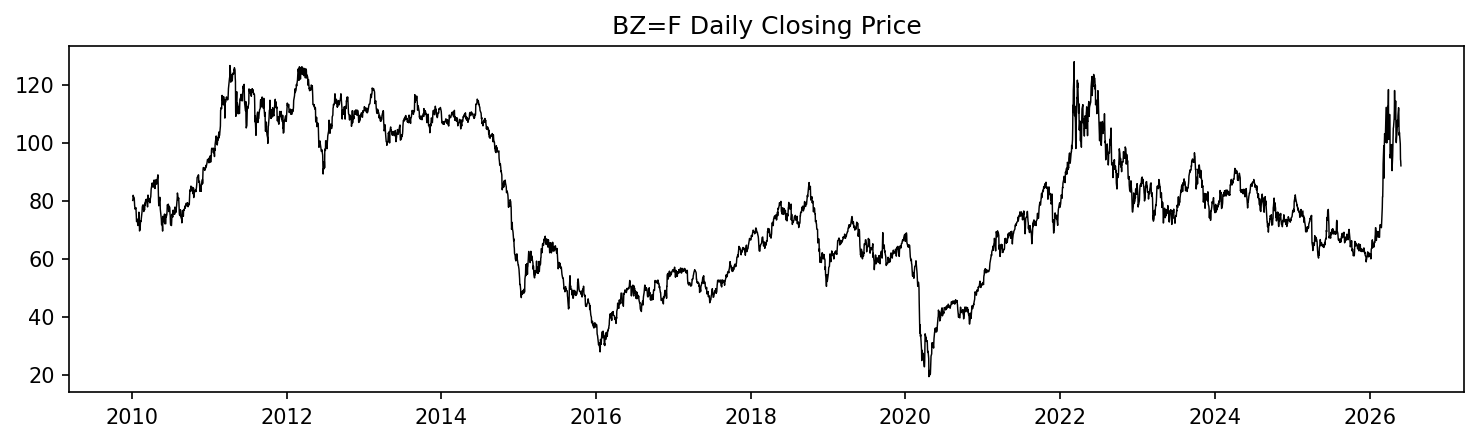

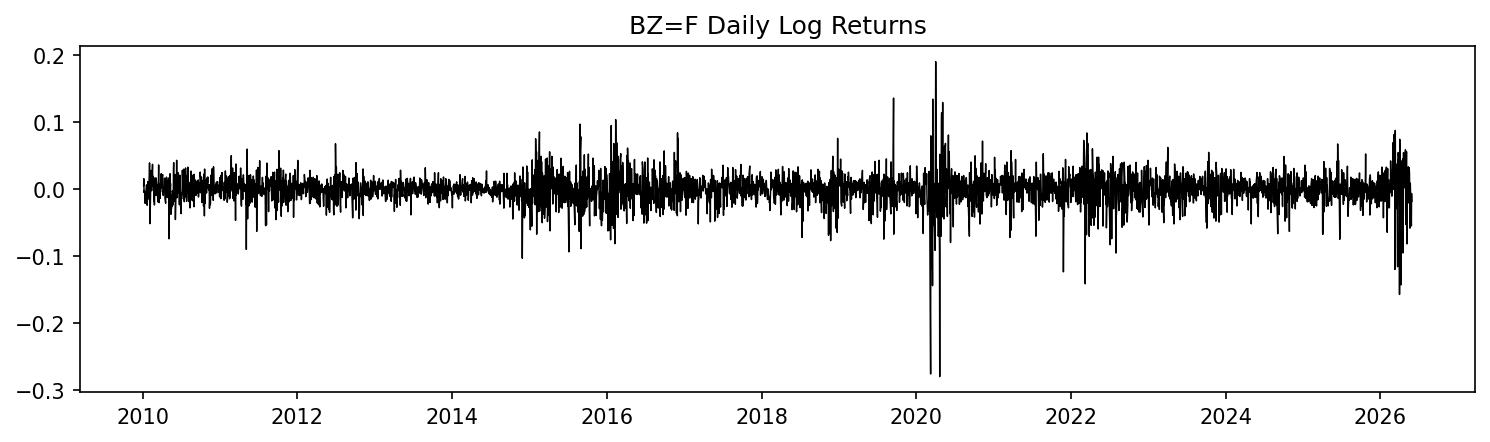

In [4]:
# Visualize the data
plt.figure(figsize=(12, 3), dpi=150)
plt.plot(close, linewidth=0.7, color='black')
plt.title(f"{TICKER} Daily Closing Price")
plt.show()

plt.figure(figsize=(12, 3), dpi=150)
plt.plot(returns.index.to_timestamp(), returns.values, label='Daily Returns', linewidth=0.7, color='black')
plt.title(f"{TICKER} Daily Log Returns")
plt.show()

In [5]:
def get_stats_and_ks(series, name):
    stats = series.describe()
    ks_stat, ks_pval = kstest(series, 'norm', args=(series.mean(), series.std()))
    result = {
        'count': stats['count'],
        'mean': stats['mean'],
        'std': stats['std'],
        'min': stats['min'],
        'max': stats['max'],
        'range': stats['max'] - stats['min'],
        'skewness': skew(series),
        'kurtosis': kurtosis(series),
        'KS_stat': ks_stat,
        'KS_pval': ks_pval,
        'Name': name
    }
    return result

stats_list = [
    get_stats_and_ks(returns, "Full Returns")
]

stats_df = pd.DataFrame(stats_list).set_index('Name')
stats_df


,count,mean,std,min,max,range,skewness,kurtosis,KS_stat,KS_pval
Name,,,,,,,,,,
Full Returns,4094.0,0.000034,0.023234,-0.279761,0.190774,0.470536,-0.997909,15.340816,0.086771,2.872243e-27


# 4. Classical Econometric Models (GARCH Family)

Five volatility specifications are estimated with three error distributions each (Normal, Student-t, GED), giving 15 models in total.

| Spec | Description |
|------|-------------|
| GARCH | Standard symmetric GARCH(1,1) — Bollerslev (1986) |
| GJR-GARCH | Asymmetric leverage effect via indicator term — Glosten et al. (1993) |
| EGARCH | Log-variance equation, asymmetric — Nelson (1991) |
| APARCH | Asymmetric power ARCH — Ding et al. (1993) |
| FIGARCH | Fractionally integrated long-memory variance — Baillie et al. (1996) |

## 4.1 In-sample fit

In [6]:
# Split returns into train / test using the date variables set above
train_returns = returns[returns.index <= TRAIN_END]
test_returns  = returns[returns.index >= TEST_START]

print(f"Train: {train_returns.index[0]}  →  {train_returns.index[-1]}  ({len(train_returns)} obs)")
print(f"Test:  {test_returns.index[0]}  →  {test_returns.index[-1]}  ({len(test_returns)} obs)")

Train: 2010-01-05  →  2022-06-30  (3110 obs)
Test:  2022-07-01  →  2026-05-29  (984 obs)


In [7]:
# Fit every model on training data and collect information criteria
insample_models: dict[str, GARCHModel] = {}
ic_rows = []

for model_type, dist in GARCH_SPECS:
    name = f"{model_type}-{dist.upper()}" 
    model = GARCHModel(model_type, dist)
    try:
        model.fit(train_returns)
        insample_models[name] = model
        row = model.info_criteria()
        row["Model"] = name
        ic_rows.append(row)
    except Exception as exc:
        print(f"  [WARNING] {name} failed in-sample fit: {exc}")

ic_df = (
    pd.DataFrame(ic_rows)
    .set_index("Model")
    .sort_values("BIC")
    [["LogL", "AIC", "BIC"]]
)
print(f"Fitted {len(insample_models)} / {len(GARCH_SPECS)} models")
ic_df

Fitted 15 / 15 models


,LogL,AIC,BIC
Model,,,
GJR-GARCH-T,-6264.173946,12540.347891,12576.602159
EGARCH-T,-6269.597063,12549.194126,12579.406016
GARCH-T,-6269.988512,12549.977024,12580.188914
APARCH-T,-6268.701121,12549.402242,12585.656510
FIGARCH-T,-6269.000674,12550.001349,12586.255617
GJR-GARCH-GED,-6276.601527,12565.203054,12601.457322
EGARCH-GED,-6282.924362,12575.848724,12606.060615
GARCH-GED,-6283.617069,12577.234138,12607.446028
APARCH-GED,-6282.159283,12576.318566,12612.572834


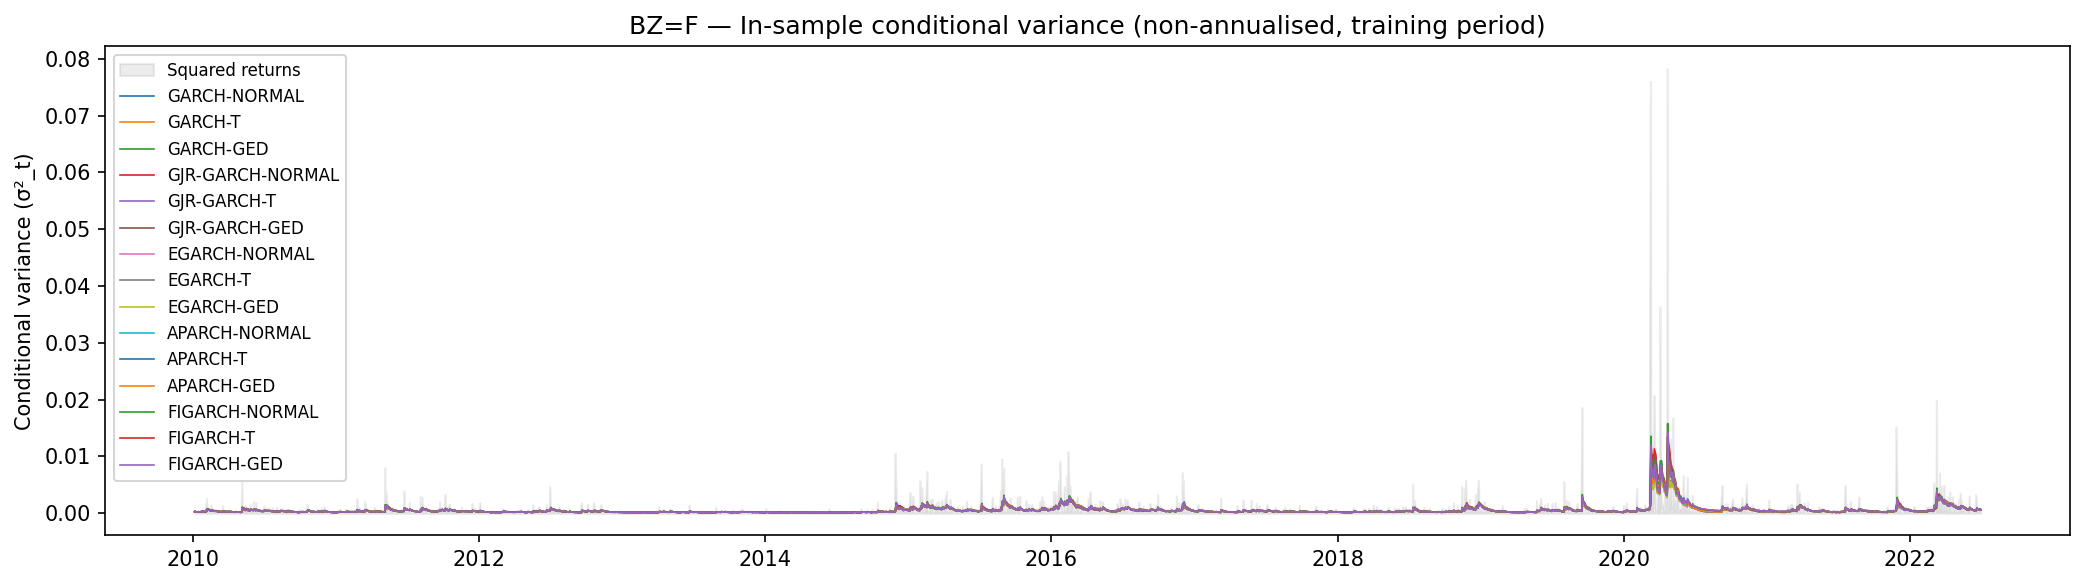

In [8]:
# In-sample conditional variance (non-annualised)
# Shows raw σ²_t as returned by each model
# PLOT_MODELS = ["GARCH-NORMAL", "GJR-GARCH-NORMAL", "EGARCH-NORMAL"]
PLOT_MODELS = [
    'GARCH-NORMAL', 'GARCH-T', 'GARCH-GED',
    'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED',
    'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED',
    'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED',
    'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED']

fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
ax.fill_between(
    train_returns.index.to_timestamp(),
    train_returns.values ** 2,
    alpha=0.15, color="gray", label="Squared returns",
)
for name in PLOT_MODELS:
    if name in insample_models:
        cv = insample_models[name].insample_variance()
        ax.plot(
            cv.index.to_timestamp(),
            cv.values,
            linewidth=0.8,
            label=name,
        )
ax.set_title(f"{TICKER} — In-sample conditional variance (non-annualised, training period)")
ax.set_ylabel("Conditional variance (σ²_t)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

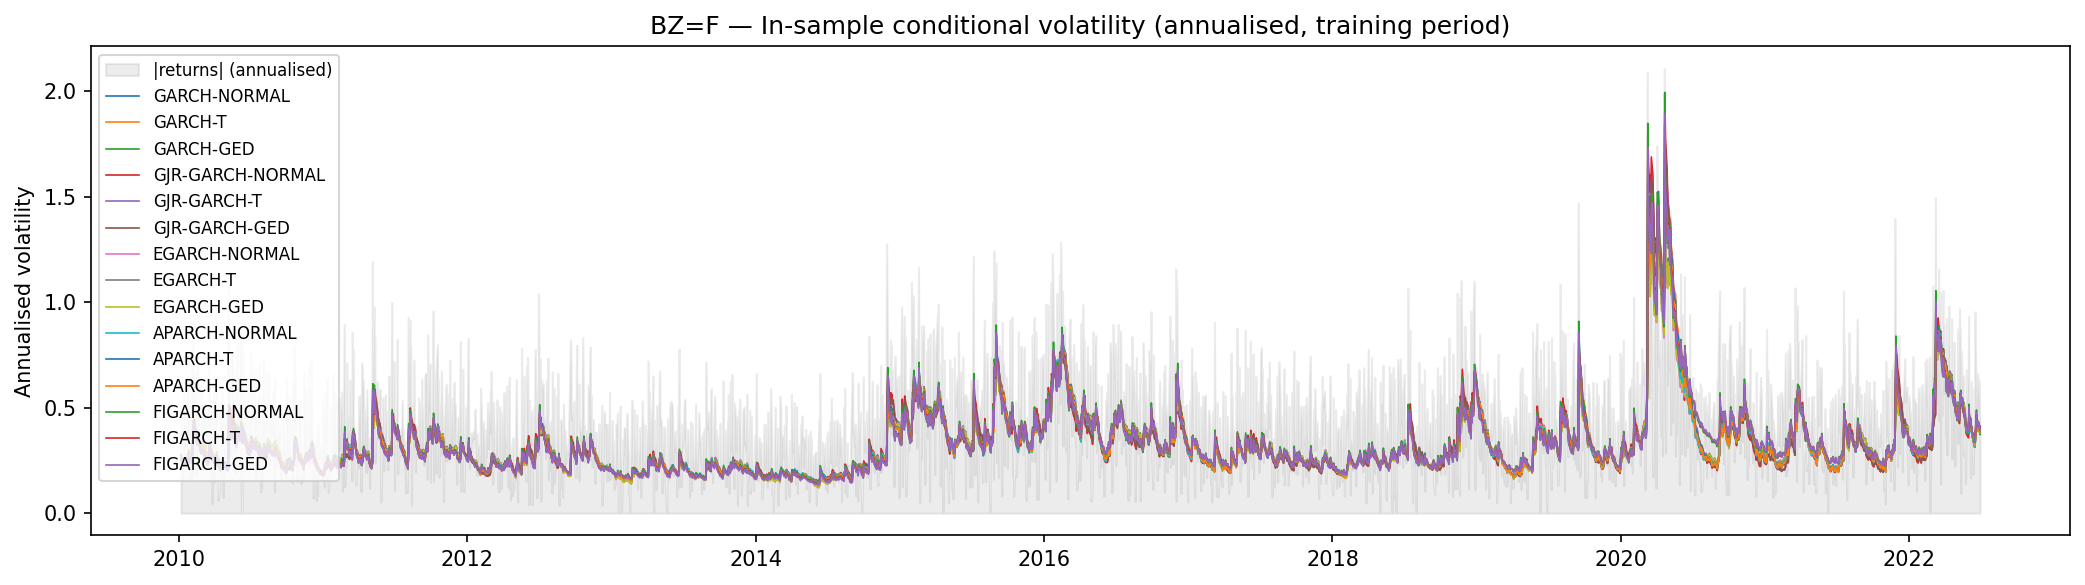

In [9]:
# In-sample conditional volatility — symmetric vs asymmetric comparison
# Shows annualised conditional standard deviation: sqrt(σ²_t × 252)
# PLOT_MODELS = ["GARCH-NORMAL", "GJR-GARCH-NORMAL", "EGARCH-NORMAL"]
PLOT_MODELS = [
    'GARCH-NORMAL', 'GARCH-T', 'GARCH-GED',
    'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED',
    'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED',
    'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED',
    'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED']

fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
ax.fill_between(
    train_returns.index.to_timestamp(),
    np.sqrt(np.abs(train_returns.values) * np.sqrt(252)),
    alpha=0.15, color="gray", label="|returns| (annualised)",
)
for name in PLOT_MODELS:
    if name in insample_models:
        cv = insample_models[name].insample_variance()
        ax.plot(
            cv.index.to_timestamp(),
            np.sqrt(cv.values * 252),
            linewidth=0.8,
            label=name,
        )
ax.set_title(f"{TICKER} — In-sample conditional volatility (annualised, training period)")
ax.set_ylabel("Annualised volatility")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4.2 Out-of-sample evaluation

Recursive one-step-ahead forecasting: at each step *t* the model is conditioned on all returns up to *t* and produces a forecast for *t+1*. Parameters are re-estimated every `REFIT_EVERY` steps.

**Window type:** `WINDOW_TYPE` — *expanding* uses all data from the start up to *t*; *sliding* keeps a fixed-width window.

**Variance proxy:** `VARIANCE_PROXY` — the realized-variance series against which forecasts are evaluated. `garman_klass` (Garman-Klass 1980) uses OHLC data and is 5–8× less noisy than squared returns, which meaningfully increases the power of the DM test and MCS.

In [10]:
evaluator = RollingEvaluator(n_ahead=N_AHEAD, refit_every=REFIT_EVERY, window_type=WINDOW_TYPE)

# Build (factory, name) pairs — default capture avoids late-binding closure issues
garch_eval_specs = [
    (lambda t=t, d=d: GARCHModel(t, d), f"{t}-{d.upper()}")
    for t, d in GARCH_SPECS
]

garch_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    garch_eval_specs,
    train_returns,
    test_returns,
    actuals_series=variance_proxy,
    verbose=True,
)
print(f"\nCompleted {len(garch_results)} models.")
print(f"Window type: {WINDOW_TYPE}  |  Proxy: {VARIANCE_PROXY}")

Evaluating GARCH-NORMAL...
  [GARCH-NORMAL] re-fitted at step 0/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 10/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 20/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 30/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 40/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 50/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 60/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 70/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 80/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 90/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 100/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 110/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 120/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 130/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 140/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 150/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 160/984 (sliding)
  [GARCH-NORMAL] re-fitted at step 170/984 (sliding)
  [GARCH-NORMAL] re-fitted at 

In [11]:
# Out-of-sample metrics table — ranked by RMSE
metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in garch_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
metrics_df

,RMSE,MAE,MSE,QLIKE
EGARCH-GED,0.002146,0.000437,0.000005,-6.454788
EGARCH-T,0.002147,0.000444,0.000005,-6.469177
EGARCH-NORMAL,0.002148,0.000445,0.000005,-6.437396
APARCH-T,0.002153,0.000440,0.000005,-6.461610
APARCH-GED,0.002153,0.000440,0.000005,-6.447888
APARCH-NORMAL,0.002157,0.000450,0.000005,-6.435553
GARCH-GED,0.002159,0.000449,0.000005,-6.452906
FIGARCH-GED,0.002160,0.000450,0.000005,-6.419939
FIGARCH-T,0.002160,0.000451,0.000005,-6.432397
GARCH-T,0.002161,0.000455,0.000005,-6.469232


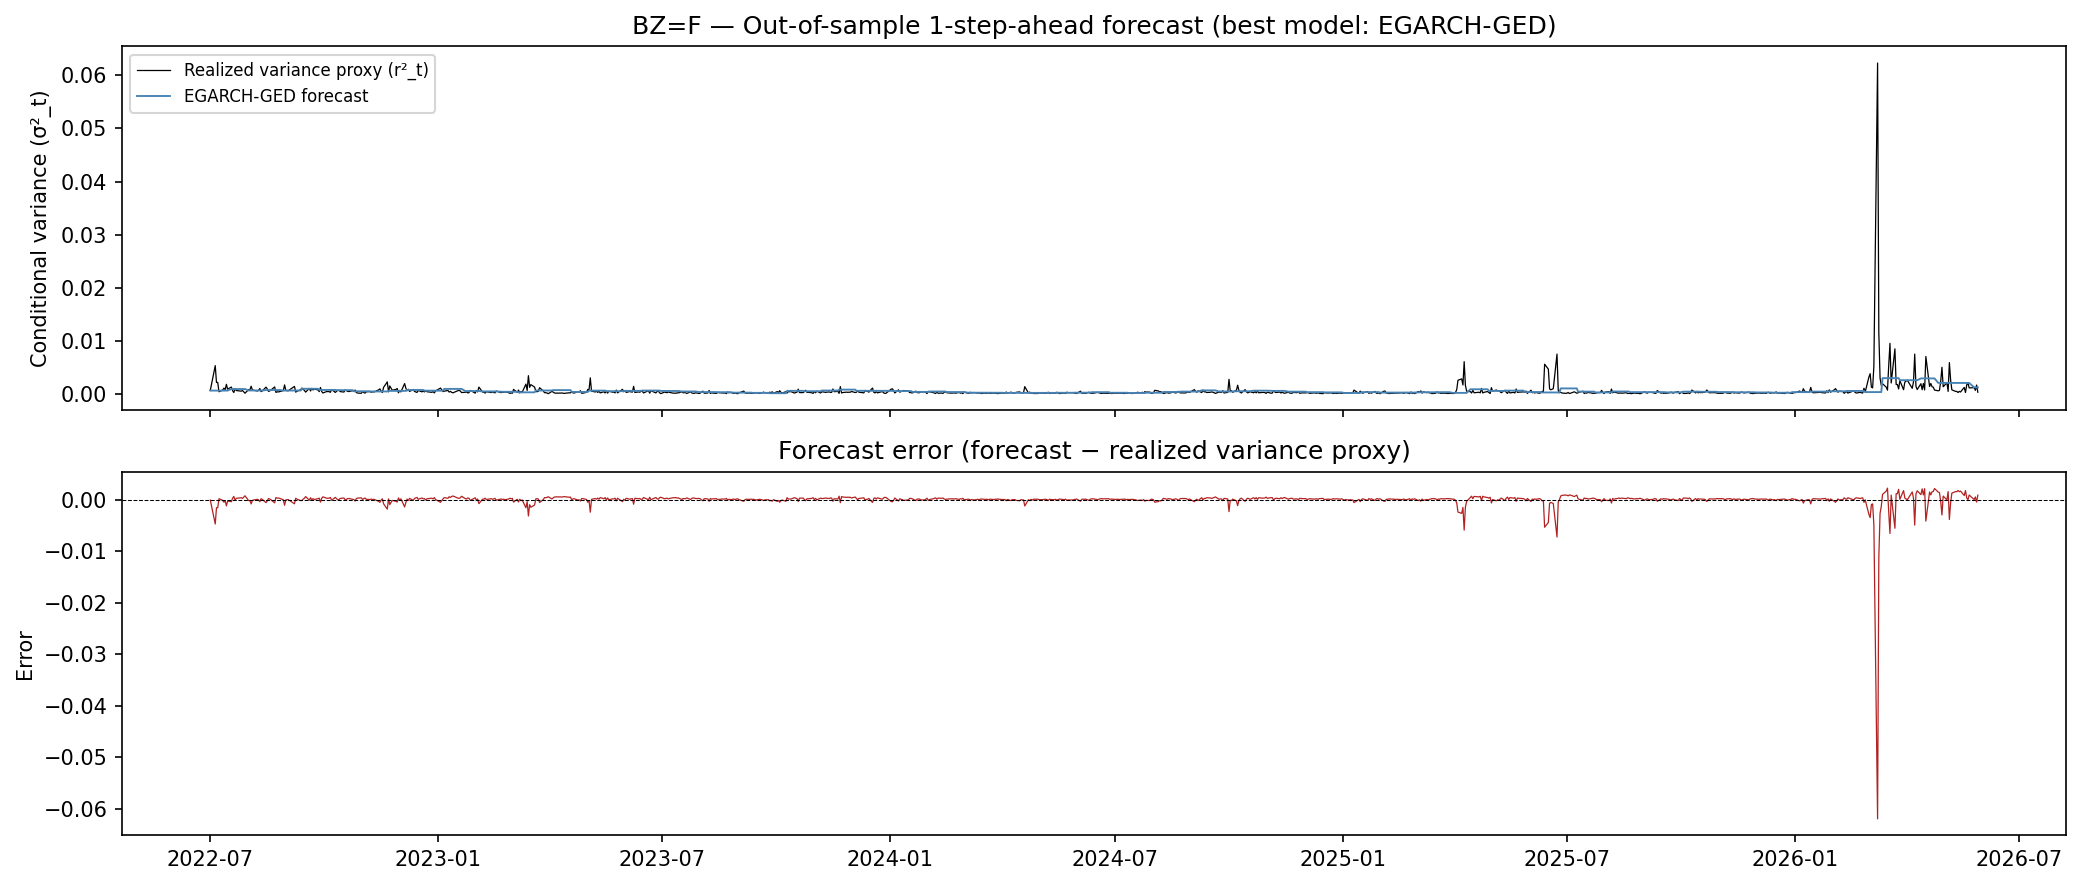

In [12]:
# Forecast vs realized — best model by RMSE (non-annualised)
# Shows raw variance: σ²_t forecast vs squared-return proxy
best_name = metrics_df.index[0]
r = garch_results[best_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)

ax0, ax1 = axes
ax0.plot(
    r.actuals.index.to_timestamp(),
    r.actuals.values,
    color="black", linewidth=0.6, label="Realized variance proxy (r²_t)",
)
ax0.plot(
    r.forecasts.index.to_timestamp(),
    r.forecasts.values,
    color="steelblue", linewidth=0.9, label=f"{best_name} forecast",
)
ax0.set_title(f"{TICKER} — Out-of-sample 1-step-ahead forecast (best model: {best_name})")
ax0.set_ylabel("Conditional variance (σ²_t)")
ax0.legend(fontsize=8)

ax1.plot(
    r.errors.index.to_timestamp(),
    r.errors.values,
    color="firebrick", linewidth=0.6,
)
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.set_title("Forecast error (forecast − realized variance proxy)")
ax1.set_ylabel("Error")

plt.tight_layout()
plt.show()

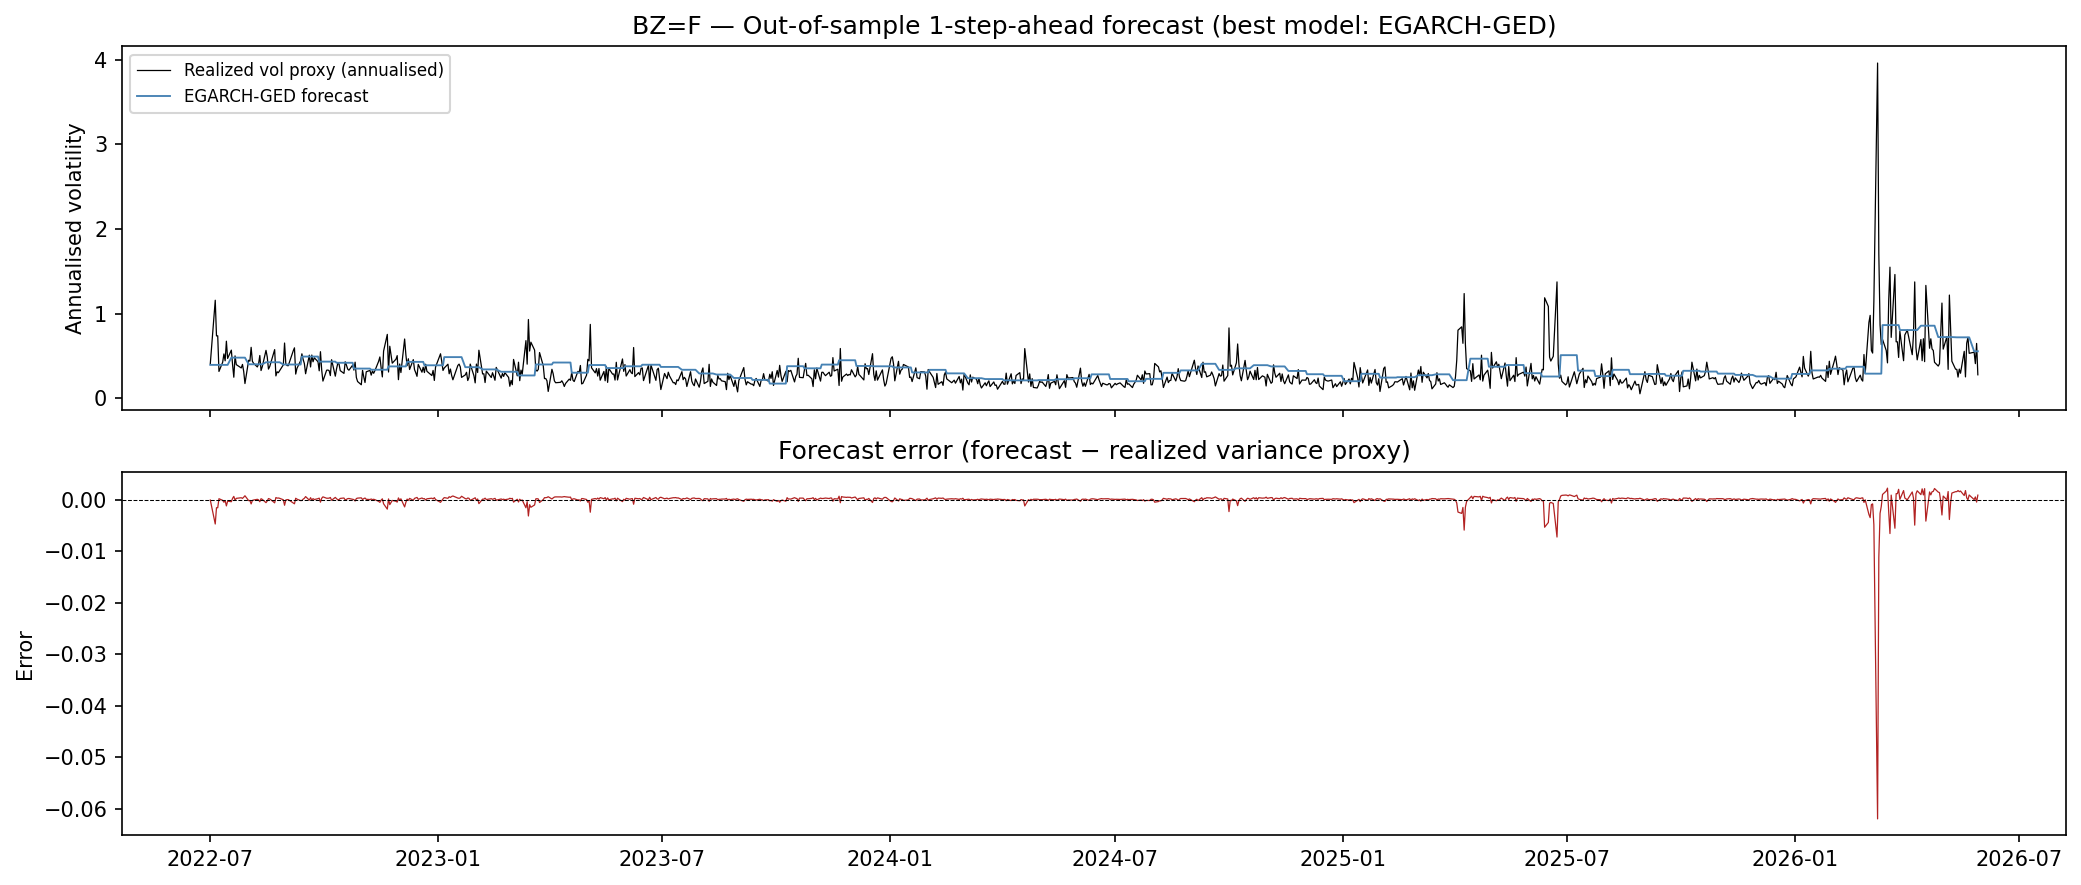

In [13]:
# Forecast vs realized — best model by RMSE
best_name = metrics_df.index[0]
r = garch_results[best_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)

ax0, ax1 = axes
ax0.plot(
    r.actuals.index.to_timestamp(),
    np.sqrt(r.actuals.values * 252),
    color="black", linewidth=0.6, label="Realized vol proxy (annualised)",
)
ax0.plot(
    r.forecasts.index.to_timestamp(),
    np.sqrt(r.forecasts.values * 252),
    color="steelblue", linewidth=0.9, label=f"{best_name} forecast",
)
ax0.set_title(f"{TICKER} — Out-of-sample 1-step-ahead forecast (best model: {best_name})")
ax0.set_ylabel("Annualised volatility")
ax0.legend(fontsize=8)

ax1.plot(
    r.errors.index.to_timestamp(),
    r.errors.values,
    color="firebrick", linewidth=0.6,
)
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.set_title("Forecast error (forecast − realized variance proxy)")
ax1.set_ylabel("Error")

plt.tight_layout()
plt.show()

# 5. Statistical Tests

## 5.1 Diebold-Mariano Test (HLN correction)

Pairwise test of equal predictive accuracy (Harvey, Leybourne & Newbold 1997).  
H₀: models *i* and *j* have equal expected loss.  
Negative MDM statistic → row model has lower loss than column model.  
p-values are two-sided from a *t*(T−1) distribution.

In [14]:
dm_stat_df, dm_pval_df = dm_matrix(garch_results, h=N_AHEAD, loss=TEST_LOSS)

print("MDM statistics (upper triangle):")
dm_stat_df.round(3)

MDM statistics (upper triangle):


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED
GARCH-NORMAL,NaN,2.108,2.140,-3.877,1.446,-1.448,-0.074,2.049,0.856,-0.344,4.736,1.220,-1.062,-0.369,-0.804
GARCH-T,NaN,NaN,-2.043,-2.781,-2.993,-2.651,-0.878,-0.002,-0.490,-1.393,-0.526,-1.050,-1.492,-1.155,-1.307
GARCH-GED,NaN,NaN,NaN,-3.201,0.120,-3.332,-0.523,0.904,0.081,-1.038,1.087,-0.386,-1.312,-0.836,-1.092
GJR-GARCH-NORMAL,NaN,NaN,NaN,NaN,2.640,2.974,1.219,3.526,2.558,3.121,5.209,5.397,0.223,1.435,0.421
GJR-GARCH-T,NaN,NaN,NaN,NaN,NaN,-2.314,-0.501,0.820,0.055,-0.909,0.801,-0.348,-1.202,-0.766,-1.009
GJR-GARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,0.117,2.143,1.016,0.094,4.341,1.470,-0.777,-0.097,-0.560
EGARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.068,2.416,-0.132,1.104,0.620,-2.260,-0.549,-1.758
EGARCH-T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.742,-2.936,-0.724,-2.103,-2.740,-2.348,-2.337
EGARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.968,0.442,-0.604,-3.112,-2.347,-2.522
APARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.593,3.106,-1.641,-0.379,-1.124


In [15]:
print("DM p-values (upper triangle) — highlighted cells: p < DM_ALPHA")
dm_pval_df.round(4).style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold"
    if (not pd.isna(v) and v < DM_ALPHA)
    else "",
)

DM p-values (upper triangle) — highlighted cells: p < DM_ALPHA


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED
GARCH-NORMAL,nan,0.035300,0.032600,0.000100,0.148500,0.148100,0.941100,0.040700,0.392000,0.731200,0.000000,0.222800,0.288500,0.712200,0.421500
GARCH-T,nan,nan,0.041300,0.005500,0.002800,0.008200,0.380200,0.998100,0.624400,0.163900,0.599200,0.294100,0.136000,0.248500,0.191500
GARCH-GED,nan,nan,nan,0.001400,0.904700,0.000900,0.601100,0.366300,0.935800,0.299500,0.277200,0.699900,0.189900,0.403300,0.275000
GJR-GARCH-NORMAL,nan,nan,nan,nan,0.008400,0.003000,0.223300,0.000400,0.010700,0.001900,0.000000,0.000000,0.823200,0.151600,0.673700
GJR-GARCH-T,nan,nan,nan,nan,nan,0.020900,0.616600,0.412300,0.956500,0.363400,0.423500,0.727600,0.229700,0.443800,0.313400
GJR-GARCH-GED,nan,nan,nan,nan,nan,nan,0.906900,0.032400,0.310000,0.924800,0.000000,0.141900,0.437100,0.922500,0.575300
EGARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,0.038900,0.015900,0.895000,0.269800,0.535300,0.024000,0.583000,0.079100
EGARCH-T,nan,nan,nan,nan,nan,nan,nan,nan,0.081800,0.003400,0.469400,0.035700,0.006200,0.019000,0.019700
EGARCH-GED,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.049400,0.658700,0.545700,0.001900,0.019100,0.011800
APARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.009700,0.002000,0.101100,0.704500,0.261400


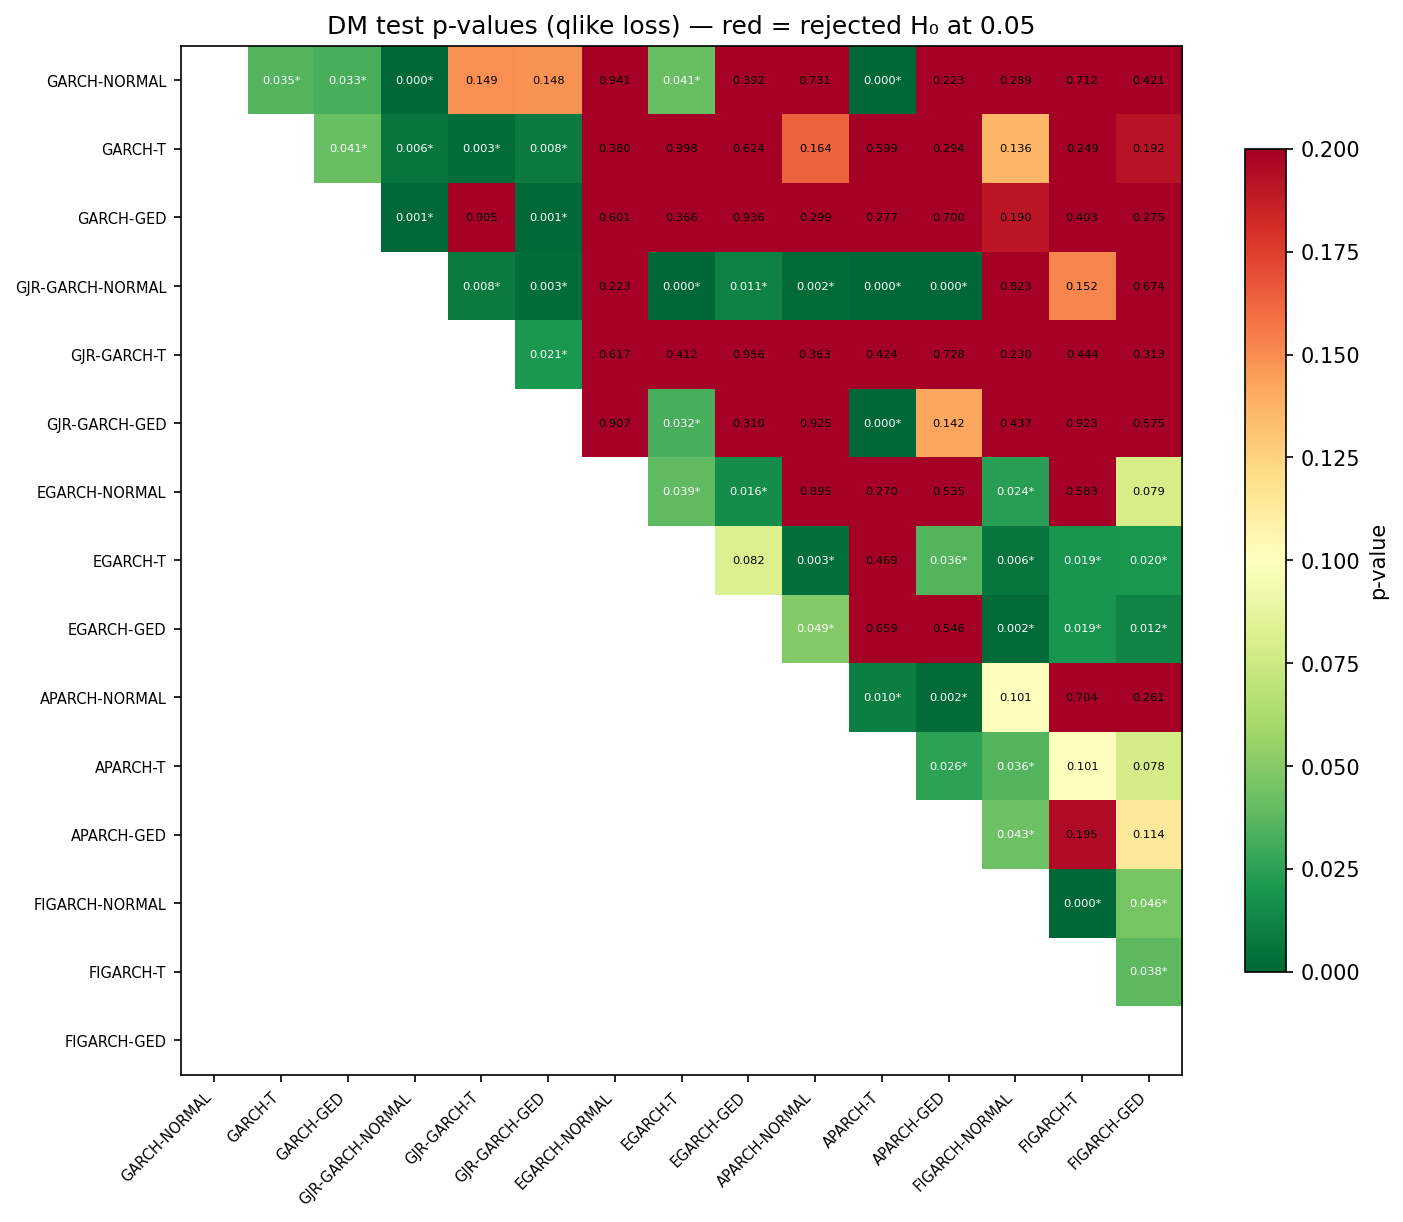

In [16]:
# DM p-value heatmap (upper triangle only)
names  = list(garch_results.keys())
n_mods = len(names)
pvals  = dm_pval_df.values.astype(float)

# Mask lower triangle + diagonal (show upper triangle only)
mask       = np.tril(np.ones_like(pvals, dtype=bool))
pvals_plot = np.where(mask, np.nan, pvals)

fig, ax = plt.subplots(figsize=(max(8, n_mods * 0.65), max(6, n_mods * 0.55)), dpi=150)
im = ax.imshow(pvals_plot, cmap="RdYlGn_r", vmin=0, vmax=0.20, aspect="auto")
plt.colorbar(im, ax=ax, label="p-value", shrink=0.8)

ax.set_xticks(range(n_mods))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_mods))
ax.set_yticklabels(names, fontsize=7)
ax.set_title(f"DM test p-values ({TEST_LOSS} loss) — red = rejected H₀ at {DM_ALPHA}")

for i in range(n_mods):
    for j in range(i + 1, n_mods):
        v = pvals[i, j]
        if not np.isnan(v):
            sig = "*" if v < DM_ALPHA else ""
            ax.text(j, i, f"{v:.3f}{sig}", ha="center", va="center", fontsize=5.5,
                    color="white" if v < 0.05 else "black")

plt.tight_layout()
plt.show()

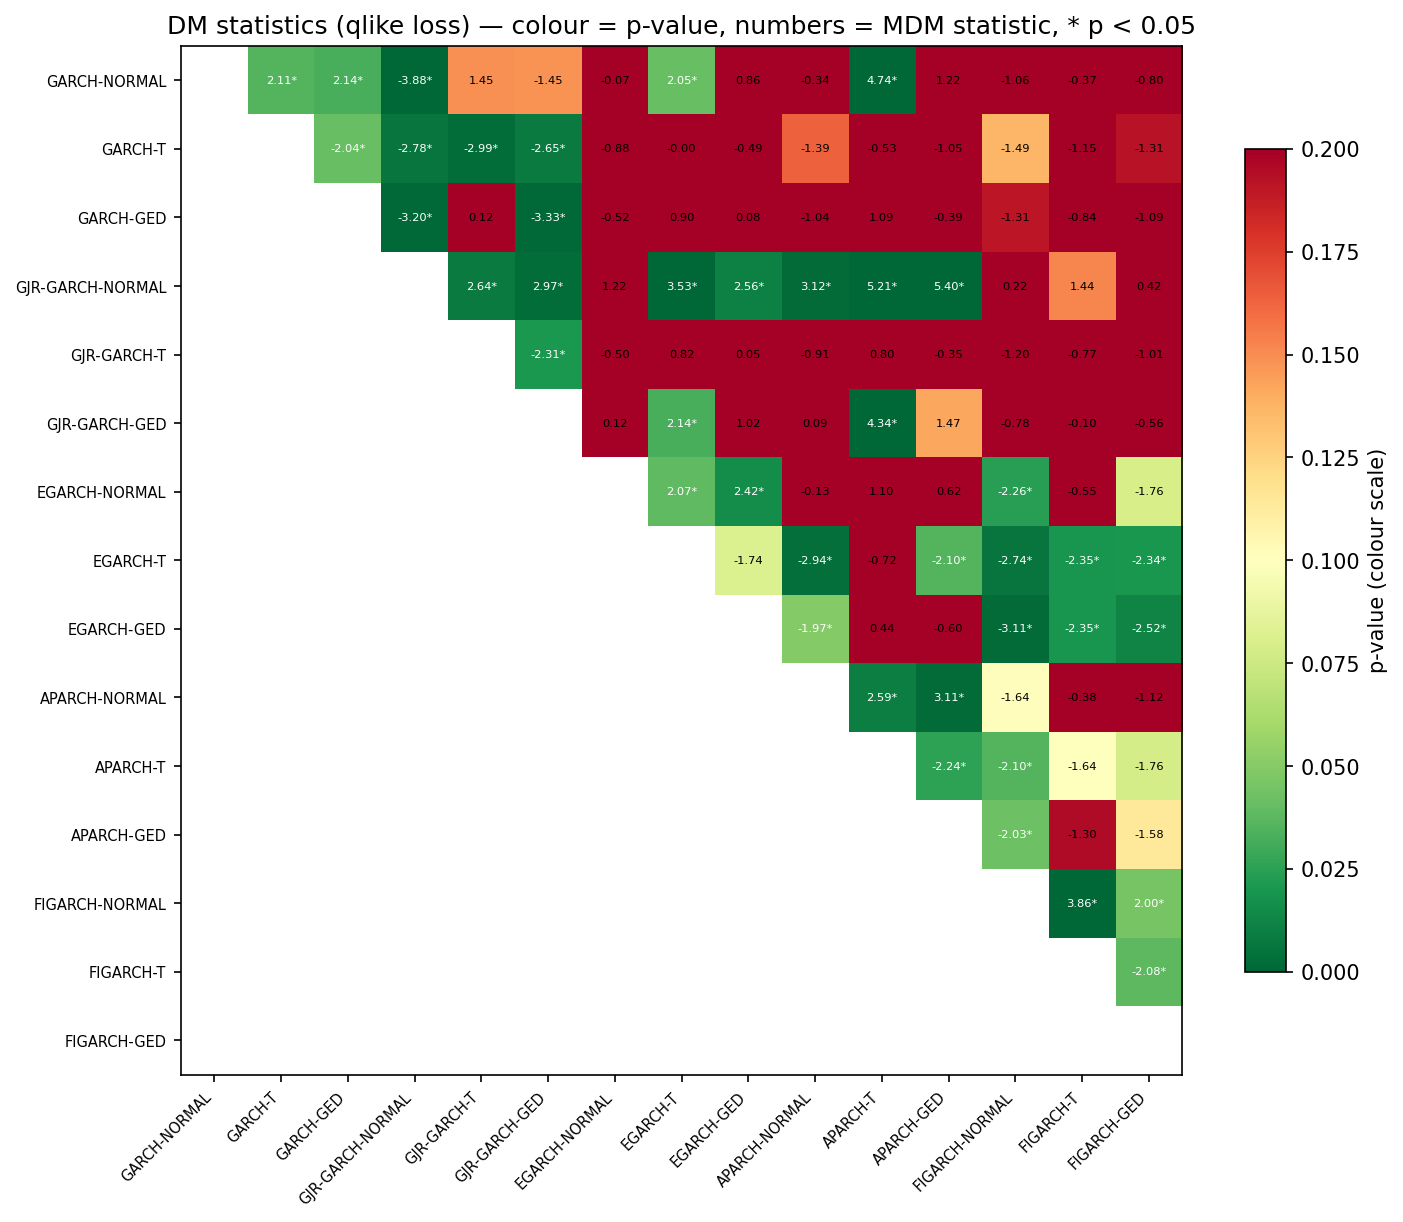

In [17]:
# DM statistics heatmap — colour based on p-value, numbers show DM statistic
names  = list(garch_results.keys())
n_mods = len(names)
pvals  = dm_pval_df.values.astype(float)
stats  = dm_stat_df.values.astype(float)

mask       = np.tril(np.ones_like(pvals, dtype=bool))
pvals_plot = np.where(mask, np.nan, pvals)
stats_plot = np.where(mask, np.nan, stats)

fig, ax = plt.subplots(figsize=(max(8, n_mods * 0.65), max(6, n_mods * 0.55)), dpi=150)
im = ax.imshow(pvals_plot, cmap="RdYlGn_r", vmin=0, vmax=0.20, aspect="auto")
plt.colorbar(im, ax=ax, label="p-value (colour scale)", shrink=0.8)

ax.set_xticks(range(n_mods))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_mods))
ax.set_yticklabels(names, fontsize=7)
ax.set_title(f"DM statistics ({TEST_LOSS} loss) — colour = p-value, numbers = MDM statistic, * p < {DM_ALPHA}")

for i in range(n_mods):
    for j in range(i + 1, n_mods):
        s = stats_plot[i, j]
        p = pvals_plot[i, j]
        if not np.isnan(s):
            sig = "*" if p < DM_ALPHA else ""
            ax.text(j, i, f"{s:.2f}{sig}", ha="center", va="center", fontsize=5.5,
                    color="white" if p < 0.05 else "black")

plt.tight_layout()
plt.show()

## 5.2 Model Confidence Set (MCS)

Hansen, Lunde & Nason (2011). Sequential elimination of the worst model using the T_max statistic until the null of equal predictive accuracy cannot be rejected. Inference via stationary bootstrap (Politis & Romano 1994).

Models with `mcs_pvalue > MCS_ALPHA` belong to the (1 − MCS_ALPHA) MCS.

In [18]:
mcs_result = mcs(
    garch_results,
    loss=TEST_LOSS,
    alpha=MCS_ALPHA,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
)
print(mcs_result)
print()
mcs_result.summary().style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["in_mcs"],
).format({"mcs_pvalue": "{:.4f}"})

MCSResult(alpha=0.05, loss='qlike', n_included=15, models=['GARCH-NORMAL', 'GARCH-T', 'GARCH-GED', 'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED', 'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED', 'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED', 'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED'])



,mcs_pvalue,in_mcs
GARCH-NORMAL,1.0000,True
GARCH-T,1.0000,True
GARCH-GED,1.0000,True
GJR-GARCH-NORMAL,1.0000,True
GJR-GARCH-T,1.0000,True
GJR-GARCH-GED,1.0000,True
EGARCH-NORMAL,1.0000,True
EGARCH-T,1.0000,True
EGARCH-GED,1.0000,True
APARCH-NORMAL,1.0000,True


### 5.2.1 MCS cross-check — arch.bootstrap.MCS (Sheppard)

Independent verification using Kevin Sheppard's `arch.bootstrap.MCS` implementation (T_max statistic).

**Interpretation:**
- If both implementations agree (same models survive / same models all-included) → the result is consistent.
- If both retain the full set with `squared` proxy but a subset survives with `garman_klass` → the earlier all-p=1 result was caused by a noisy proxy, not an implementation bug.
- If the two implementations disagree for the same proxy → there is a bug in our custom MCS.

In [19]:
arch_mcs_result = arch_mcs(
    garch_results,
    loss=TEST_LOSS,
    size=MCS_ALPHA,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
)

print(f"arch.bootstrap.MCS — {TEST_LOSS} loss, alpha={MCS_ALPHA}")
print(f"Models in MCS: {arch_mcs_result['in_mcs'].sum()} / {len(arch_mcs_result)}")
print()

# Side-by-side comparison with our MCS
comparison = mcs_result.summary().rename(columns={"mcs_pvalue": "our_pvalue", "in_mcs": "our_in_mcs"})
comparison = comparison.join(
    arch_mcs_result.rename(columns={"mcs_pvalue": "arch_pvalue", "in_mcs": "arch_in_mcs"})
)
comparison.style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["our_in_mcs", "arch_in_mcs"],
).format({"our_pvalue": "{:.4f}", "arch_pvalue": "{:.4f}"})

arch.bootstrap.MCS — qlike loss, alpha=0.05
Models in MCS: 15 / 15



,our_pvalue,our_in_mcs,arch_pvalue,arch_in_mcs
GARCH-NORMAL,1.0000,True,0.5880,True
GARCH-T,1.0000,True,1.0000,True
GARCH-GED,1.0000,True,0.7950,True
GJR-GARCH-NORMAL,1.0000,True,0.0620,True
GJR-GARCH-T,1.0000,True,0.7950,True
GJR-GARCH-GED,1.0000,True,0.5880,True
EGARCH-NORMAL,1.0000,True,0.7060,True
EGARCH-T,1.0000,True,0.9985,True
EGARCH-GED,1.0000,True,0.8220,True
APARCH-NORMAL,1.0000,True,0.2520,True
